# Heart Disease Prediction

## 2. Dimensionality Reduction - PCA

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

In [2]:
# Load the cleaned and scaled dataset
df = pd.read_csv("heart_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (920, 19)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,num,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6,thal_7
0,63,1,145,233,1,150,0,2.3,0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,67,1,160,286,0,108,1,1.5,3,2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,67,1,120,229,0,129,1,2.6,2,1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,37,1,130,250,0,187,0,3.5,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41,0,130,204,0,172,0,1.4,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [3]:
X = df.drop(columns=["target"]) if "target" in df.columns else df.copy()
y = df["target"] if "target" in df.columns else None

# Applying PCA
pca = PCA()
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

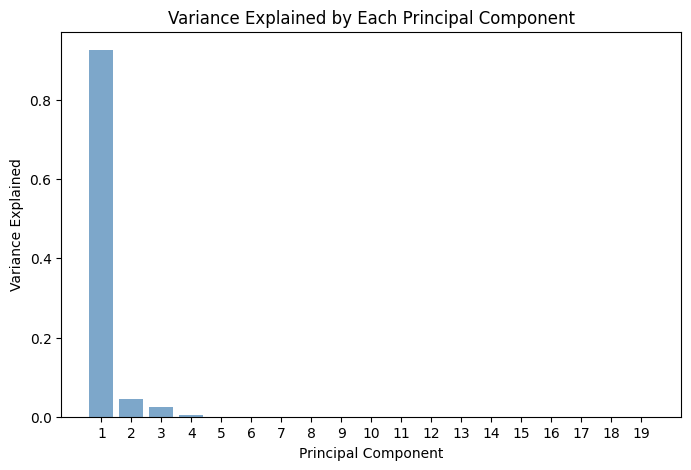

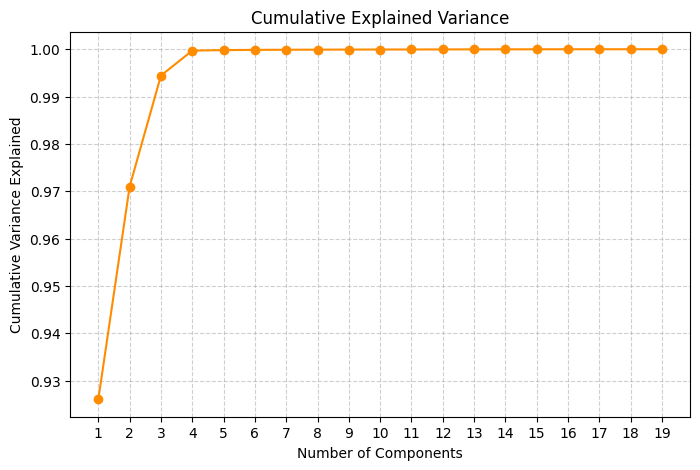

In [4]:
# Bar chart
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color="steelblue")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Variance Explained by Each Principal Component")
plt.xticks(np.arange(1, len(explained_variance)+1))  # force integer ticks
plt.show()

# Cumulative variance plot
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker="o", color="darkorange")
plt.xticks(np.arange(1, len(cumulative_variance)+1))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Explained Variance")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

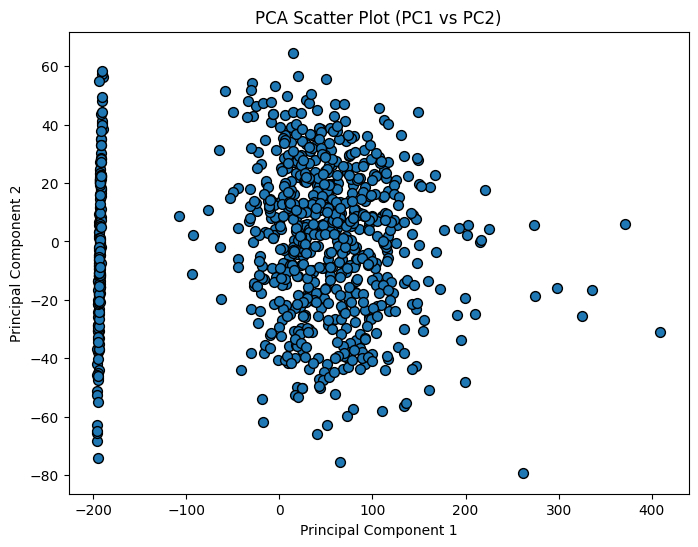

In [5]:
# Scatter plot for the first two principal components
plt.figure(figsize=(8,6))

if y is not None:
    # Color points by target class
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", edgecolor="k", s=50)
    plt.colorbar(label="Target")
else:
    # If no target column is present
    plt.scatter(X_pca[:,0], X_pca[:,1], edgecolor="k", s=50)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot (PC1 vs PC2)")
plt.show()


In [6]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Optimal number of components to retain 95% variance: {n_components}")

pca_opt = PCA(n_components=n_components)
X_pca_opt = pca_opt.fit_transform(X)

Optimal number of components to retain 95% variance: 2


In [7]:
# Save PCA-transformed dataset
df_pca = pd.DataFrame(X_pca_opt, columns=[f"PC{i+1}" for i in range(n_components)])
if y is not None:
    df_pca["target"] = y.values

df_pca.to_csv("heart_pca.csv", index=False)
print("PCA-transformed dataset saved as heart_pca.csv")

PCA-transformed dataset saved as heart_pca.csv
